# Økonomisk kriminalitet
Formålet her er ikke å undervise i økonomisk kriminalitet.  Eksemplene vi har valgt er derfor syntetiske.

## Datamodell

Vi velger en (svært) enkel datamodell som "til en viss grad" reflekterer økonomisk kriminalitet.

### Noder
Følgende er noder:
- **Peroner**: Har relasjoner til andre personer, eier konti, og gjennomfører transkasjoner;
- **Konto** som tilhører en person, og
- **Transaksjoner** og relasjonene til konto og person gir kontekst.  En transaksjon har en type, som er enten
   - Uttak
   - Innskudd, eller
   - Overføring

    Transaksjonen holder alltid et beløp.

### Relasjoner (kanter)
- **Kjenner** er relasjonen mellom to personer.  Det er åpenbart en (veldig) forenkling av virkeliheten, med godt nok.
- **Kontoeier** er relasjonen fra en konto til en person
- **Fra** og **Til** knytter en konto til en annen konto gjennom en transkasjon av typen **Overføring**.
- **Overføring**, **Innskudd**, og **Uttak** knytter en person gjennom en transaksjon (med riktig type) til en konto.

Et uttak er en transaksjon med relasjon til en konto og en person.  En overføring er en transaksjon (node) med relasjon til to konti og til to personer (totalt fire relasjoner).

Datamodellen vil begrense hva vi kan representere.  Det vil si at med denne enkle modellen er begrenset til å studere "enkle" representasjoner av strukturelle egenskaper.  Mer om det senere.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import uuid
import scipy
from datetime import datetime, timedelta

### Navn
Norske navn fra SSB som vi legger til nodene.  Data 
[her](https://www.ssb.no/statbank/sq/10117977).  Forstår ikke hvorfor de kommer som Latin-1 og ikke UTF-8; noe å undersøke en dag jeg har god tid.

In [2]:
# Norske navn.
# Formatet er: "Navn";Antall
norskenavn = []
with open("data/guttenavn.csv", "r", encoding="Latin-1") as fd:
    for linje in fd:
        navn = linje.split(";")[0]
        norskenavn.append(navn[1:-1])
    #
#
with open("data/jentenavn.csv", "r", encoding="Latin-1") as fd:
    for linje in fd:
        navn = linje.split(";")[0]
        norskenavn.append(navn[1:-1])
    #
#
print(f"Lastet {len(norskenavn)} navn")

Lastet 2123 navn


### Personer

Slik ser en person ut, og alle personer har konto (i det minste for tiden).

Returnerer en graf med to noder: Personen og kontoen.

In [3]:
def lag_person_konto(navn=None):
    if navn == None:
        navn = random.choice(norskenavn)
    G = nx.Graph()
    uid = str(uuid.uuid4())
    G.add_node(uid, Person=True)
    G.nodes[uid]["Navn"] = navn
    kto = str(uuid.uuid4())
    G.add_node(kto, Konto=True)
    G.add_edge(uid, kto, Kontoeier=True)
    return (G, uid, kto)
#fed

In [4]:
# Gitt to konti, send penger.
#
# Premisset er at begge kontoene eies av én person (hver)
def lag_overføring_konti(G, fra, til, beløp, tidspunkt):
    sender = None
    for u, v, attr in G.edges(fra, data=True):
        if "Kontoeier" in attr:
            # Dette er linken til eieren
            sender = v
            break
        #
    #
    assert sender, f"Konto {sender} har ingen eier"
    mottaker = None
    for u, v, attr in G.edges(til, data=True):
        if "Kontoeier" in attr:
            # Dette er linken til eieren
            mottaker = v
            break
        #
    #
    assert mottaker, f"Konto {mottaker} har ingen eier"

    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               Transaksjon = True,
               Overføring = True,
               Fra = fra,
               Til = til,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til sendende konto
    G.add_edge(fra, transId, Fra=True)
    # ...og til mottakende konto
    G.add_edge(transId, til, Til=True)
    # Knytt transaksjonen til senderen
    G.add_edge(transId, sender, Overføring=True)
    # ....og til mottakeren
    G.add_edge(transId, mottaker, Overføring=True)

    return transId
#

In [5]:
# Gitt to personer, send penger.
#
def lag_overføring_person(G, fra_p, til_p, beløp, tidspunkt):
    # Finn kontoene
    sender = None
    for u, v, attr in G.edges(fra_p, data=True):
        if "Kontoeier" in attr:
            # Dette er kontoen
            sender = v
            break
        #
    #
    assert sender, f"Konto {sender} har ingen eier"
    mottaker = None
    for u, v, attr in G.edges(til_p, data=True):
        if "Kontoeier" in attr:
            # Dette er linken til kontoen
            mottaker = v
            break
        #
    #
    assert mottaker, f"Konto {mottaker} har ingen eier"

    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               Transaksjon = True,
               Overføring = True,
               Fra = fra_p,
               Til = til_p,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til sendende konto
    G.add_edge(sender, transId, Fra=True)
    # ...og til mottakende konto
    G.add_edge(transId, mottaker, Til=True)
    # Knytt transaksjonen til senderen
    G.add_edge(transId, fra_p, Overføring=True)
    # ....og til mottakeren
    G.add_edge(transId, til_p, Overføring=True)

    return transId
#

In [6]:
# En person tar ut penger fra en konto
def person_uttak(G, person, beløp, tidspunkt):
    # Finn kontoen
    kto = None
    for u, v, attr in G.edges(person, data=True):
        if "Kontoeier" in attr:
            # Dette er linken til kontoen
            kto = v
            break
        #
    #
    assert kto, f"Personen {person} hadde ikke konto"

    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               Transaksjon = True,
               Uttak = True,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til kontoen
    G.add_edge(kto, transId, Uttak=True)
    # Knytt transaksjonen til eieren
    G.add_edge(transId, person, Uttak=True)
    
    return transId
#    
    

In [7]:
# En person setter inn penger på sin konto
def person_innskudd(G, person, beløp, tidspunkt):
    assert person in G
    
    # Finn kontoen
    kto = None
    for u, v, attr in G.edges(person, data=True):
        if "Kontoeier" in attr:
            # Dette er kontoen
            kto = v
            break
        #
    #
    assert kto, f"Personen {person} hadde ikke konto"
    
    # Lag selve transaksjonen
    transId = str(uuid.uuid4())
    G.add_node(transId, 
               Transaksjon = True,
               Innskudd = True,
               Beløp=beløp,
               Tidspunkt = tidspunkt.isoformat())
    # Knytt transaksjonen til mottakende konto
    G.add_edge(kto, transId, Innskudd=True)
    # Knytt transaksjonen til eieren
    G.add_edge(transId, person, Innskudd=True)
    
    return transId
#    

## Kriminalitet

### "Money Mule"
Alle medlemmene i en klikk, unntatt én som vi kaller M, tar ut penger.  Deretter (i tid) setter Bakmannen, som M har relasjon til, et beløp som er noe mindre enn summen av det som er tatt ut.  Det endelige innskuddet skjer naturligvis en stund etter at alle uttakene er gjort.
Uttakene spres utover i tid (fra nå og fremover) og beløpet varierer opp til en grense.  M tar ikke ut penger (han får dem i kontanter).

Vi lager en klikk (og derfor en graf) og setter opp alle realsjonene.

In [8]:

def lag_money_mule(antall_personer, total_beløp):
    # Uttakene skjer innen dette vinduet
    vindu_uttak = 8 
    #ANtall dager senere innskuddet skjer
    når_skjer_innskuddet = 2
    
    # Lager personene og setter dem sammen til én graf, og lager så en klikk
    personer = nx.Graph()
    folk = []
    konti = {}
    for i in range(antall_personer):
        person, uid, kto = lag_person_konto()
        konti[uid] = kto
        personer = nx.compose(personer, person)
        folk.append(uid) # Mennesker reduseres til UUID - slik er livet
    #
    # Lag subgraf av personene (ikke deres konti)
    S = personer.subgraph(folk)
    # Dette skaper en kopi
    S = nx.complete_graph(S)
    # Sett typen på kantene
    nx.set_edge_attributes(S, True, "kjenner")
    personer = nx.compose(personer, S)

    # Finn den som skal være forbryteren.
    M = random.choice(folk)
    print(f"Den skyldige er: {personer.nodes[M]["Navn"]}: {M}")

    # Legg til en bakmann med konto
    bakmann, bak_uid, bak_kto = lag_person_konto("Bakmann")
    personer = nx.compose(personer, bakmann)
    # M kjenner bakmannen
    personer.add_edge(M, bak_uid, Kjenner=True)

    # Alle setter inn penger og sender dem til M
    bak_beløp = 0 # Totalt beløp tatt ut
    for person in folk:
        # Unntatt M, hen gjør noe annet
        if personer == M:
            continue
        #
        transId = str(uuid.uuid4())
        beløp = round(total_beløp * random.random(), 2)
        tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random())
        t = person_innskudd(personer, person, beløp, tidspunkt)
        t = lag_overføring_konti(personer, person, M, beløp, tidspunkt)
    #

    # M tar ut pengene
    tidspunkt = datetime.now() + timedelta(hours=vindu_uttak * random.random())
    t = person_uttak(personer, M, beløp, tidspunkt)

    # M fraker pengene til bakmannen, som setter dem inn
    # M får bonus

    tidspunkt = datetime.now() + timedelta(days=når_skjer_innskuddet)
    t = person_innskudd(personer, bak_uid, bak_beløp - round(bak_beløp * random.random() * 0.25, 2), tidspunkt)
    return personer
#fed



Den skyldige er: Ask: 3a65effa-6ccc-4d14-aabb-821d909af056


<Figure size 500x500 with 0 Axes>

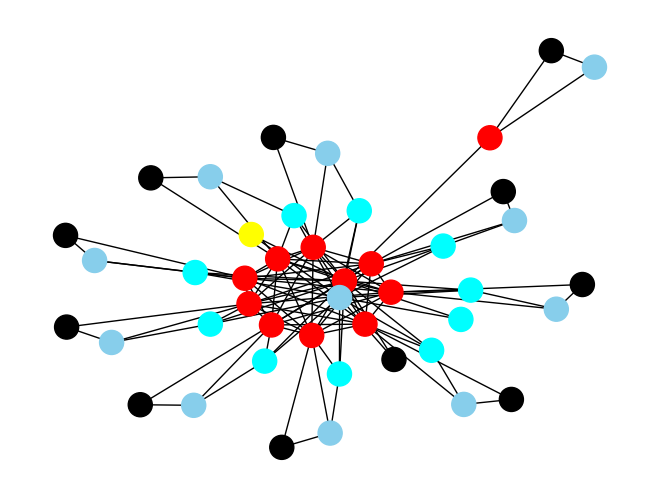

<Figure size 500x500 with 0 Axes>

In [9]:
#
# Lag og se

#
#
MM = lag_money_mule(10, 1000)
#
#


# Fjern identifikatorene
#G = nx.convert_node_labels_to_integers(G)
# Tegne
node_farge = []
for n,d in MM.nodes(data=True):
    if "Person" in d:
        node_farge += ["red"]
    elif "Konto" in d:
        node_farge += ["skyblue"]
    elif "Uttak" in d:
        node_farge += ["yellow"]
    elif "Innskudd" in d:
        node_farge += ["black"]
    elif "Transaksjon" in d:
        node_farge += ["cyan"]
    else:
        node_farge += ["green"]
    #
#
pos = nx.spring_layout(MM, seed=42)  # Be nodene spre seg utover så godt de kan
nx.draw(MM, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))



In [10]:
#
G5 = lag_money_mule(5, 1000000)
G10 = lag_money_mule(10, 1000000)
G15 = lag_money_mule(15, 20000000) # 20 millioner

nx.write_graphml(G5, "grafer/Mule5.graphml")
nx.write_graphml(G10, "grafer/Mule10.graphml")
nx.write_graphml(G15, "grafer/Mule15.graphml")


Den skyldige er: Justin: 704dd8fd-548f-4f13-99b8-7af3e4642d8d
Den skyldige er: Bjørn-Erik: b7122fa3-6a85-4f73-97ec-30dfa259c132
Den skyldige er: Shirin: 3461ac5b-c599-4c90-930c-8ea618b7409f


### Bakmann
En som knytter sammen flere klikker

In [11]:
def bakmann_klikker(antall_klikker, antall_personer):
    # Antall_klikker er, vel, antall klikker
    # antall_personer er i hver klikk +- 25%
    assert(antall_klikker > 0)
    assert(antall_personer > 0)
    
    klikker = []
    for k in range(antall_klikker):
        klikk = nx.Graph()
        folk = []
        # Litt variasjon i antall folk i hver klikk
        for i in range(antall_personer + int(antall_personer/4*random.uniform(-1, 1))):
            person, uid, _ = lag_person_konto()
            # Legg personen til i klikken
            klikk = nx.compose(klikk, person)
            folk.append(uid)
        #
        # Lag subgraf av personene (ikke deres konti)  En subgraf er et "view"
        S = klikk.subgraph(folk)
        # Konvertere til en klikk; operasjoen skaper en kopi
        S = nx.complete_graph(S)
        # Sett typen på kantene
        nx.set_edge_attributes(S, True, "kjenner")
        # Slå dem sammen; networkx sikrer at det skjer som planlagt
        klikk = nx.compose(klikk, S)
        klikker.append(klikk)
    #

    # Her er bakmannen
    bakmann, bak_uid, _ = lag_person_konto("Bakmann")
    
    for klikk in klikker:
        # velg en node i klikken (trist å måtte konvertere klikken til en liste, men det er hva det er)
        folk = []
        for n, attr in klikk.nodes(data=True):
            if "Person" in attr:
                folk.append(n)
            #
        #
        medlem = random.choice(folk)
        # Ta inn klikken
        bakmann = nx.compose(bakmann, klikk)
        bakmann.add_edge(bak_uid, medlem, Kjenner=True)
        print(bakmann)
    #

    return(bakmann)
#fed


Graph with 22 nodes and 57 edges
Graph with 42 nodes and 113 edges
Graph with 62 nodes and 169 edges
Graph with 82 nodes and 225 edges
Graph with 106 nodes and 304 edges


<Figure size 500x500 with 0 Axes>

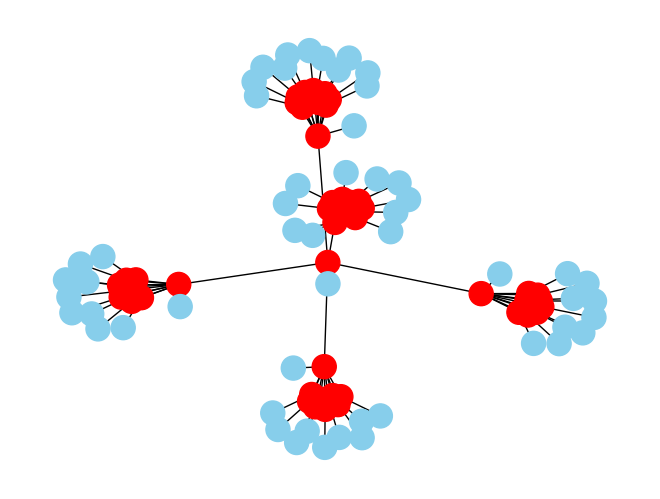

<Figure size 500x500 with 0 Axes>

In [12]:

G = bakmann_klikker(5, 10)
# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "Person" in d:
        node_farge += ["red"]
    elif "Konto" in d:
        node_farge += ["skyblue"]
    elif "Transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"]
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


Lagre en graf med bakimann

In [13]:
G = bakmann_klikker(5, 10)
nx.write_graphml(G5, "grafer/Bakmann.graphml")


Graph with 20 nodes and 47 edges
Graph with 44 nodes and 126 edges
Graph with 64 nodes and 182 edges
Graph with 84 nodes and 238 edges
Graph with 104 nodes and 294 edges


### Utbytte
Én stor transaksjon som tilsynelatende "spittes" i flere og sprer seg utover.  Det starter med ett stort innskudd av kontanter, som så spres utover flere personer.  Tiden går, samtidig som beløpet blir mindre

Dele en pengesum på et antall mennesker, mer eller mindre jevnt, innen et max og et min per person

For N personer, del beløpet opp i N-biter, pluss-minus 20%.  LEgg det som måtte være igjen til én av dem

In [14]:
def del_beløp(beløp, antall):
    penger = []
    igjen = beløp
    for p in range(antall):
        andel = beløp / antall * random.uniform(0.8, 1.2)
        if andel >= igjen:
            penger.append(round(igjen, 2))
            igjen = 0
        else:
            penger.append(round(andel, 2))
            igjen -= andel
        #
    #
    if igjen > 0:
        penger[0] += round(igjen, 2)
    #
    return penger
#


In [15]:

a = del_beløp(5000, 5)
print(a)
print(sum(a))

[1303.97, 1026.51, 839.9, 1016.31, 813.31]
5000.0


In [54]:
# Er beløpet mindre enn dette, da beholder du det
MINIMUM_BELØP = 5000
CUT = 15 # inntil, i prosent

# Denne er rekursiv
def del_utbyttet(G, bakmann, beløp, klokken):
    # Lag personen som nå skal bli bakmann
    person, uid, kto = lag_person_konto()
    NY = nx.compose(G, person)
    NY.add_edge(bakmann, uid, Kjenner=True)
    # Her kommer pengene
    lag_overføring_person(NY, bakmann, uid, beløp, klokken)
    
    if beløp < MINIMUM_BELØP:
        #print(f"Beløpet {beløp} deles ikke")
        print(f"Slutter med {NY.number_of_edges()} kanter og {NY.number_of_nodes()} noder")
        return NY
    #
    
    beløp -= round(int(beløp * random.randint(1, CUT) / 100), 2)
    # Vi gjør jobben litt senere i dag
    nå = klokken + timedelta(days=random.random())
    # Hvor mange vi deler med avhenger av hvor stort beløpet er (logaritmisk, HEX)
    import math
    antall = round(math.log(beløp, 10))
    bøtter = del_beløp(beløp, antall)
    print(f"Beløpet {beløp} skal deles slik: {bøtter}")
    for b in bøtter:
        delt = del_utbyttet(NY, uid, b, nå)
        NY = nx.compose(NY, delt)
    #rof bøtter
    return NY
#fed


Vi lager en bakmann, deler opp beløpet, og kaller rekursivt til beløpet er b rukt opp

Beløpet 6510 skal deles slik: [1648.6399999999999, 1934.82, 1461.27, 1465.27]
Slutter med 15 kanter og 9 noder
Slutter med 21 kanter og 12 noder
Slutter med 27 kanter og 15 noder
Slutter med 33 kanter og 18 noder
Graph with 18 nodes and 33 edges


<Figure size 500x500 with 0 Axes>

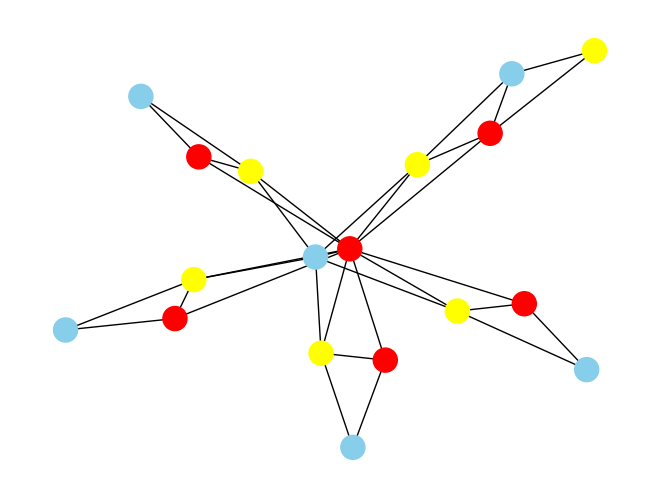

<Figure size 500x500 with 0 Axes>

In [55]:
BELØP = 7000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)
print(G)

# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "Person" in d:
        node_farge += ["red"]
    elif "Konto" in d:
        node_farge += ["skyblue"]
    elif "Transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"] # Bør ikke være noen
    #
#

pos = nx.spring_layout(G)  # Be nodene spre seg utover så godt de kan
nx.draw(G, with_labels=False, node_color=node_farge, node_size=300)
plt.figure(figsize=(5,5))


Beløpet 69300 skal deles slik: [13912.08, 14112.06, 15669.78, 12905.31, 12700.77]
Beløpet 12104.08 skal deles slik: [3213.32, 3010.31, 3299.11, 2581.34]
Slutter med 21 kanter og 12 noder
Slutter med 27 kanter og 15 noder
Slutter med 33 kanter og 18 noder
Slutter med 39 kanter og 21 noder
Beløpet 13830.06 skal deles slik: [3175.42, 3651.6, 3212.87, 3790.16]
Slutter med 51 kanter og 27 noder
Slutter med 57 kanter og 30 noder
Slutter med 63 kanter og 33 noder
Slutter med 69 kanter og 36 noder
Beløpet 14886.78 skal deles slik: [3754.54, 3565.46, 4438.54, 3128.25]
Slutter med 81 kanter og 42 noder
Slutter med 87 kanter og 45 noder
Slutter med 93 kanter og 48 noder
Slutter med 99 kanter og 51 noder
Beløpet 11228.31 skal deles slik: [3377.65, 2416.68, 2839.2, 2594.77]
Slutter med 111 kanter og 57 noder
Slutter med 117 kanter og 60 noder
Slutter med 123 kanter og 63 noder
Slutter med 129 kanter og 66 noder
Beløpet 11303.77 skal deles slik: [2655.38, 3294.81, 2895.63, 2457.94]
Slutter med 141 k

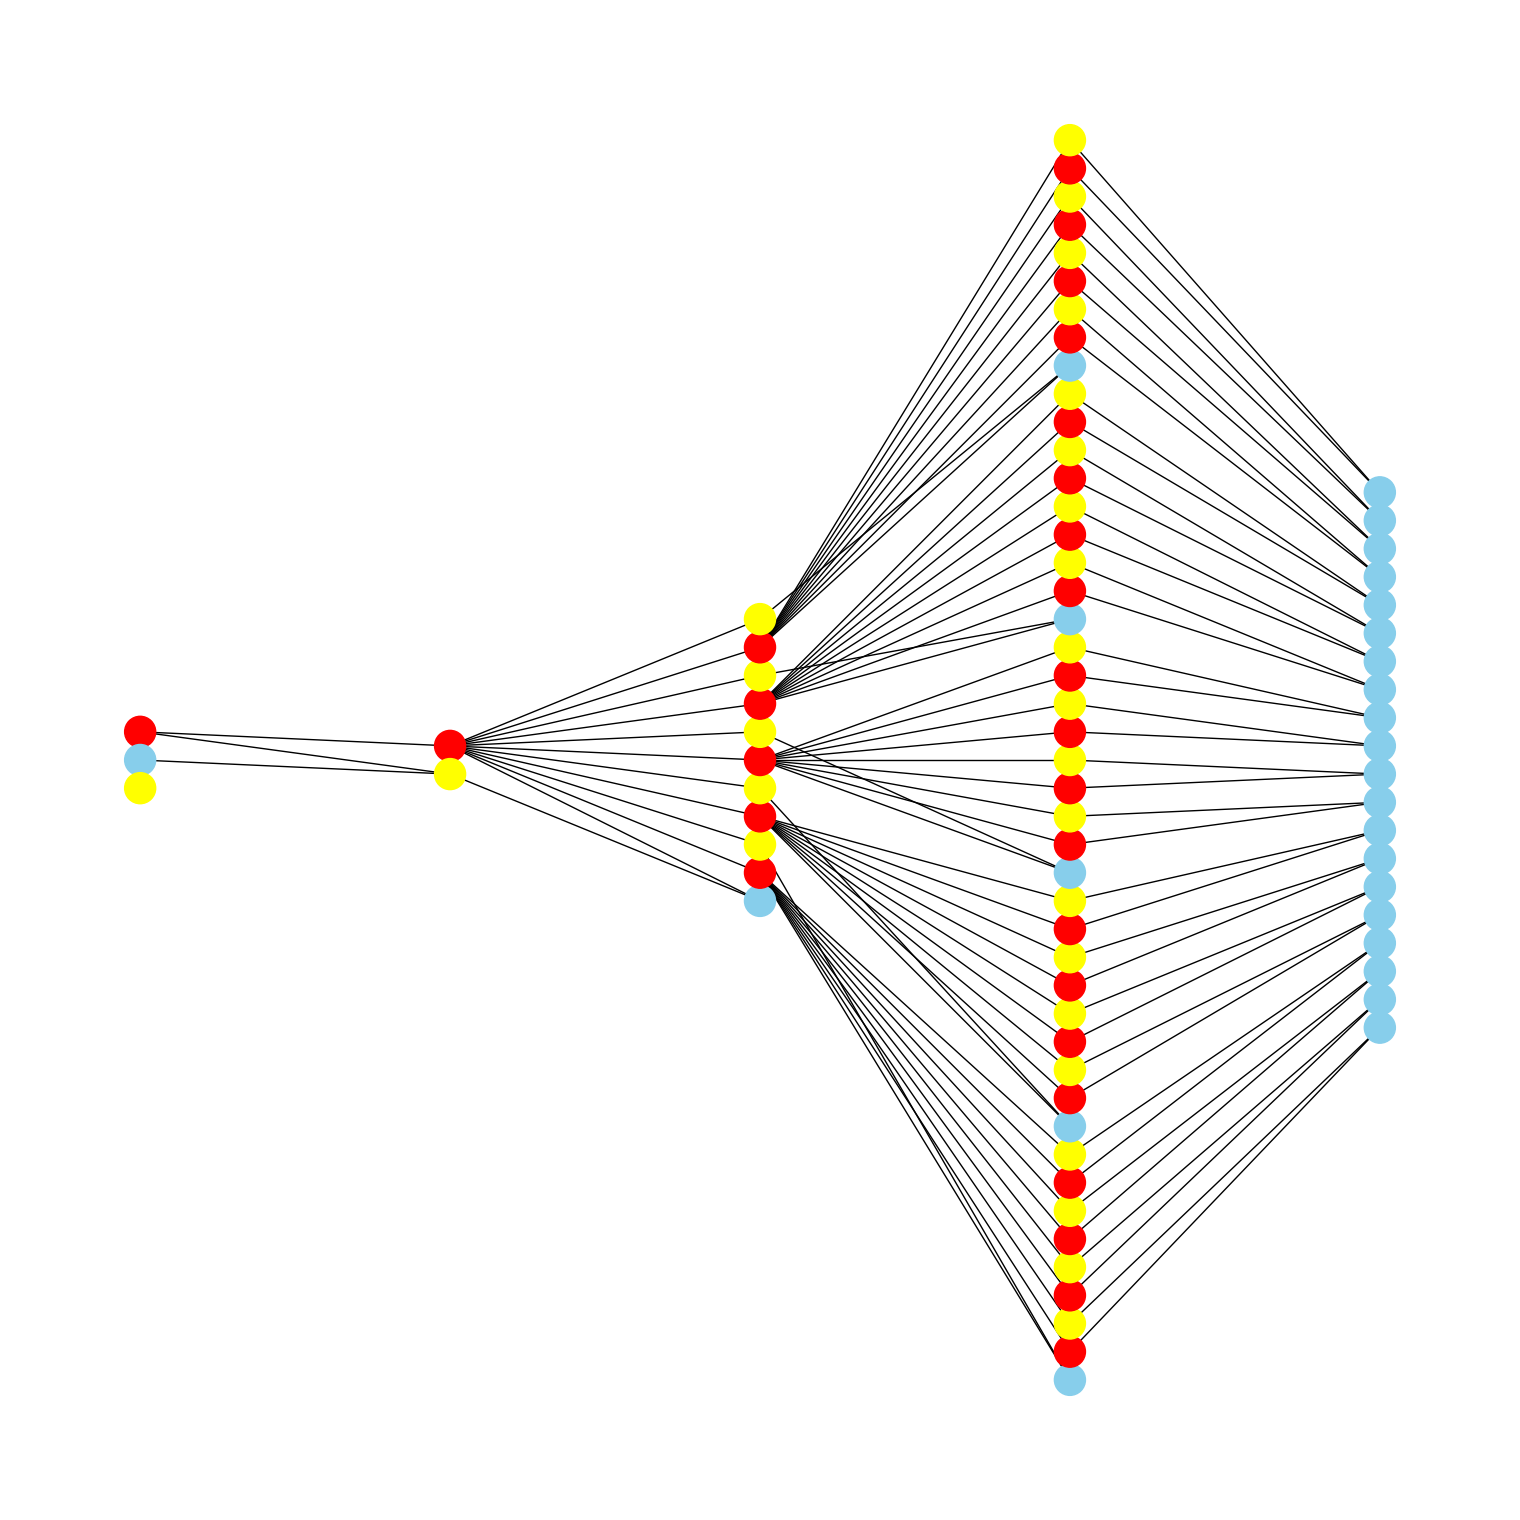

In [52]:
BELØP = 70000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)
print(G)

# Tegne
node_farge = []
for n,d in G.nodes(data=True):
    if "Person" in d:
        node_farge += ["red"]
    elif "Konto" in d:
        node_farge += ["skyblue"]
    elif "Transaksjon" in d:
        node_farge += ["yellow"]
    else:
        node_farge += ["green"] # Bør ikke være noen
    #
#

# Vis frem
pos = nx.bfs_layout(G, start=bakmann)
plt.figure(figsize=(15, 15))

nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=500)
plt.show()

In [49]:
BELØP = 70000
bakmann, b_uid, b_kto= lag_person_konto("Bakmann")
nå = datetime.now()
person_innskudd(bakmann, b_uid, BELØP, nå)
senere = nå + timedelta(hours=random.random())
G = del_utbyttet(bakmann, b_uid, BELØP, senere)
print(G)
nx.write_graphml(G, "grafer/Utbytte.graphml")


Starter med 3 kanter og 3 noder
Beløpet 67900 skal deles slik: [12126.08, 12955.01, 13367.99, 15882.65, 13568.26]
Starter med 9 kanter og 6 noder
Beløpet 10550.08 skal deles slik: [2842.19, 2143.58, 2427.06, 3137.25]
Starter med 15 kanter og 9 noder
Slutter med 21 kanter og 12 noder
Starter med 21 kanter og 12 noder
Slutter med 27 kanter og 15 noder
Starter med 27 kanter og 15 noder
Slutter med 33 kanter og 18 noder
Starter med 33 kanter og 18 noder
Slutter med 39 kanter og 21 noder
Slutter med 39 kanter og 21 noder
Starter med 39 kanter og 21 noder
Beløpet 11530.01 skal deles slik: [3347.2599999999998, 2787.66, 2433.69, 2961.4]
Starter med 45 kanter og 24 noder
Slutter med 51 kanter og 27 noder
Starter med 51 kanter og 27 noder
Slutter med 57 kanter og 30 noder
Starter med 57 kanter og 30 noder
Slutter med 63 kanter og 33 noder
Starter med 63 kanter og 33 noder
Slutter med 69 kanter og 36 noder
Slutter med 69 kanter og 36 noder
Starter med 69 kanter og 36 noder
Beløpet 12565.99 skal d